In [1]:
#import proxUtil
import PF_wrapper as PF
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import MDS

#from aeon.datasets import load_gunpoint
from aeon.datasets import load_japanese_vowels

In [2]:
#X, y = load_gunpoint(split="TRAIN", return_type='numpy2d')
X3, y3 = load_japanese_vowels(split="TRAIN")
X3t, y3t = load_japanese_vowels(split="TEST")

In [3]:
# missing mechanisms here?

In [4]:
#Xdf = pd.DataFrame(X)
#ydf = pd.DataFrame(y)

In [5]:
def aeonToFile(X3, filename, entry_separator = ',', array_separator = ':'):

    with open(filename, 'w') as f:
        # Loop over the first dimension (the "planes")
        for plane in X3:
            # Loop over the second dimension (the "rows")
            for i, row in enumerate(plane):
                # Convert the row to a string, joining with the item separator
                row_str = entry_separator.join(str(item) for item in row)
                
                # Write the row string to the file
                f.write(row_str)
                
                # Add the sub-array separator if not the last row
                if i < len(plane) - 1:
                    f.write(array_separator)
            
            # Add a newline after each plane
            f.write('\n')

In [6]:
aeonToFile(X3, 'Data/ThreeDdata.txt')
aeonToFile(X3t, 'Data/ThreeDdata_test.txt')

In [7]:
y3df = pd.DataFrame(y3)
y3df.to_csv("Data/ThreeDlabels.csv", index=False, header=None)

y3tdf = pd.DataFrame(y3t)
y3tdf.to_csv("Data/ThreeDlabels_test.csv", index=False, header=None)

In [8]:
#Xdf.to_csv("Data/GunPointMissing.csv", index=False, header=None)
#ydf.to_csv("Data/GunPointMissingLabels.csv", index=False, header=None)

In [9]:
# manual missingness...

In [10]:
dir1 = "training_output"
dir2 = "training_predictions"

In [11]:
# First, we train a PF model and give it the name 'Spartacus'
# By default, this will create a number of files (names can be specified by arguments):
    #1. Spartacus.ser: the serialized trained model
    #2. ytrain.txt: the training labels, used in computing outlier scores later
    #3. ForestProximities.txt: the array of proximities
    #4. Predictions.txt: the predictions on the given test data.

#proxUtil.PF_Train("Data/GunPoint_TRAIN.csv", test_file="Data/GunPoint_TEST.csv", return_proximities=True,
#                  model_name="Spartacus", output_directory=dir1, row_separator="\t")

#proxUtil.PF_Train("Data/GunPoint_missing_TRAIN.tsv", model_name="Spartacus", 
#                  return_proximities=True, output_directory=dir1, row_separator="\t",
#                 impute_training_data=True, return_imputed_training=True)

#proxUtil.PF_Train("Data/GunPointMissing.csv", test_file="Data/GunPointMissing.csv", model_name="Spartacus", 
#                  return_proximities=True, output_directory=dir1, row_separator=",",
#                 train_labels="Data/GunPointMissingLabels.csv", test_labels="Data/GunPointMissingLabels.csv", impute_training_data=True,
#                 return_imputed_training=True, impute_testing_data=True, return_imputed_testing=True, impute_iterations=2)

#PF.PF_Train("Data/differentlengths.txt", test_file="Data/differentlengths_test.txt", distances=['dtw_d'], 
#                  train_labels="Data/differentlabels.txt", test_labels="Data/differentlabels_test.txt",
#                  return_proximities=True, output_directory=dir1, array_separator=":", entry_separator=",", 
#                  model_name="diditwork", data_dimension=2, return_training_outlier_scores=True,
#           impute_training_data=True, return_imputed_training=True, impute_testing_data=True,
#           return_imputed_testing=True, impute_iterations=5)

PF.train("Data/ThreeDdata.txt", test_file="Data/ThreeDdata_test.txt", distances=['dtw_i', 'dtw_d'], 
                  train_labels="Data/ThreeDlabels.csv", test_labels="Data/ThreeDlabels_test.csv",
                  return_proximities=True, output_directory=dir1, array_separator=":", entry_separator=",", 
                  model_name="Spartacus", data_dimension=2, return_training_outlier_scores=True,
           num_trees=100, parallel_train=True, r=5, parallel_prox=True)

# When training, the test/validation data is not strictly needed.
#proxUtil.getProx("Data/GunPoint_TRAIN.tsv", modelname="Spartacus", out=dir1)

#This implementation has been expanded so as to handle user-specified distance(s):
#proxUtil.getProx("Data/GunPoint_TRAIN.tsv", testfile="Data/GunPoint_TEST.tsv", modelname="Spartacus", distances=['dtw','ddtw'])

#In particular, Euclidean distance for time-independent data
#proxUtil.getProx("Data/GunPoint_TRAIN.tsv", testfile="Data/GunPoint_TEST.tsv", modelname="Spartacus", distances=['euclidean'])

#One can also use a python-specified distance. A file called 'PythonDistance.py' must be in the directory the .jar file is called,
    # the function must be called 'Distance' See the PythonDistance.py file for an example and acceptable call signature.
#proxUtil.getProx("Data/GunPoint_TRAIN.tsv", testfile="Data/GunPoint_TEST.tsv", modelname="Spartacus", distances=['python'], num_trees=11)

# Similarly, one can use a function defined by a MapleDistances.mpl file (in particular, for Manifold distances)
#proxUtil.getProx("Data/GunPoint_TRAIN.tsv", testfile="Data/GunPoint_TEST.tsv", modelname="Spartacus", distances=['maple'], num_trees=11)


0:3mb
finished in 0:0:0.066

0:15mb
finished in 0:0:0.036

-----------------Repetition No: 1 (ThreeDdata.txt)   -----------------
Using: 4 MB, Free: 13 MB, Allocated Pool: 17 MB, Max Available: 1024 MB
core.ProximityForestResult@2f4d3709
2.1.3.4.0.7.6.5.8.9.11.14.12.13.15.10.16.17.19.20.23.22.18.21.24.25.26.27.28.30.29.31.33.32.36.35.34.37.38.39.40.41.42.45.44.43.46.47.48.49.52.51.50.53.54.55.56.59.58.57.60.62.63.61.64.65.66.68.67.69.71.72.73.70.74.76.75.77.78.79.80.82.83.81.84.85.86.87.88.89.91.90.92.93.94.95.96.97.99.98.
Using: 72 MB, Free: 87 MB, Allocated Pool: 159 MB, Max Available: 1024 MB
****
Training Time: 4122.691209ms (0:0:4.122)
Prediction Time: 1309.904867ms (0:0:1.309)
Correct(TP+TN): 363 vs Incorrect(FP+FN): 7
Accuracy: 0.981081081081081
Error Rate: 0.018918918918918948
REPEAT:1 ,ThreeDdata.txt, 0.981081081081081, 4122.691209, 1309.904867, 4.47
Computing Training Proximities...
Computing Training Outlier Scores...
Computing Test/Train Proximities...
Done Computing Test/

In [12]:
# Here are the predictions on the provided test set.
f0 = open(dir1 + "/Validation_Predictions.txt")
f1 = f0.read()
preds = eval("np.array(" + f1 + ")")
f0.close()

In [13]:
# We can now read a model by name and obtain predictions on another dataset. This creates:
    #1. Predictions_saved.txt: the predicted labels of the read-in model.
# Let's get predictions on the training set to illustrate.
PF.predict(dir1 + "/Spartacus", "Data/ThreeDdata.txt", test_labels="Data/ThreeDlabels.csv",
           output_directory=dir2, entry_separator=",", array_separator=":", data_dimension=2)
# Now let's get predictions on the test set.
PF.predict(dir1 + "/Spartacus", "Data/ThreeDdata_test.txt", test_labels="Data/ThreeDlabels_test.csv",
           entry_separator=",", array_separator=":", data_dimension=2)


0:3mb
finished in 0:0:0.056

***

0:3mb
finished in 0:0:0.061

****


In [14]:
# Here are the predictions (of the saved model) on the training set.
f0 = open(dir2 + "/Predictions_saved.txt")
f1 = f0.read()
train_preds_saved = eval("np.array(" + f1 + ")")
f0.close()

In [15]:
# Here are the predictions (of the saved model) on the test set.
f0 = open("Predictions_saved.txt")
f1 = f0.read()
preds_saved = eval("np.array(" + f1 + ")")
f0.close()

In [16]:
print(len(train_preds_saved))
print(len(preds_saved))
print(len(preds))

270
370
370


In [17]:
# Just checking: are the outputs of the saved model equal to the original predictions?
np.unique([preds[i]-preds_saved[i] for i in range(len(preds))])

array([0])

In [18]:
# Here is a simple helper function to read in the proximity arrays:
def getArray(filename):
    # this simply reads the Java arrays as numpy arrays.
    # Intended for outlier scores and proximities.
    f1 = open(filename)
    f2 = f1.read()
    f2 = f2.replace("{","[")
    f2 = f2.replace("}","]")
    #exec("Arr = np.array(" + f2 + ")")
    Arr = eval("np.array(" + f2 + ")")
    return Arr

In [19]:
# the following can be used to obtain the training proximities
p=getArray(dir1 + "/TrainingProximities.txt")

In [20]:
p.shape

(270, 270)

In [21]:
# We can also access the test/train proximities
pt=getArray(dir1 + "/TestTrainProximities.txt")

In [22]:
pt.shape

(370, 270)

In [23]:
# The raw proximities are not symmetric. But in some applications, one desires symmetry.
p = 0.5*(p + p.transpose())

In [24]:
# The following can be used to obtain outlier scores for the training set.
# Note that these are intra-class outlier scores.
outlier_scores = getArray(dir1 + "/outlier_scores.txt")
outlier_scores.shape

(270,)

In [25]:
# The proximities can be used to obtain a vector embedding.
# we will prepare a visual, using size to indicate intra-class outlier-ness.
embed = MDS(n_components=2, random_state=0, dissimilarity='precomputed')
dis = (np.ones(p.shape) - p)**4
x_trans = embed.fit_transform(dis)
xt = x_trans.transpose()
#sizes = [x*100 for x in outlier_scores]

/home/ben/.local/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


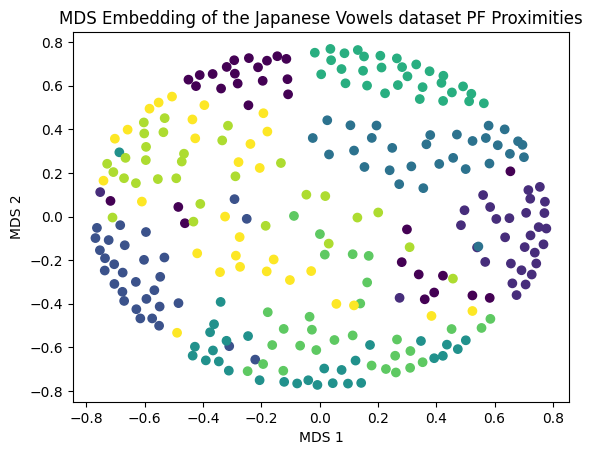

In [26]:
plt.scatter(xt[0],xt[1],c=train_preds_saved)
plt.title("MDS Embedding of the Japanese Vowels dataset PF Proximities")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.show()